In [42]:
import json
import matplotlib
import numpy as np
import igraph as ig
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.metrics.pairwise import haversine_distances

In [2]:
#read the road network
G = nx.read_gexf("erd.gexf")

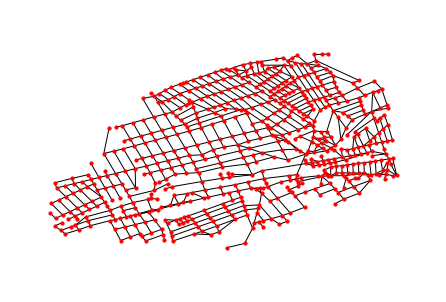

In [3]:
#create positions: pos is for plotting in degrees, posT for distance calculations in radians
pos = {}
posT = {}
for n, d in G.nodes(data=True):
    lat = float(d["x"])
    lon = float(d["y"])
    pos[n] = (lat, lon)
    posT[n] = (lon/180.0*np.pi, lat/180.0*np.pi)

nx.draw(G, pos, node_size=10, with_labels=False, node_color='red')
plt.show()

In [4]:
#Add attributes to edges
# length: the length in 7m units
# cars: th number of cars on this road. I suggest coloring by cars/length
nx.set_edge_attributes(G, values = 1, name = 'length')
nx.set_edge_attributes(G, values = 0, name = 'cars')

In [ ]:
#calculate the length of the array. Also create storage for the cars 0 forward 1 backward
roads0 = dict()
roads1 = dict()
for e in G.edges(data=True):
    l = haversine_distances([posT[e[1]]],[posT[e[0]]])[0][0]*6371000
    roads0[e[2]['id']] = np.zeros(max(1,int(l/7)),dtype=int)
    roads1[e[2]['id']] = np.zeros(max(1,int(l/7)),dtype=int)
    e[2]['length'] = max(1,(int(l/7)+1)//2)

In [6]:
e

('5906163981', '5906165120', {'id': '981', 'length': 7, 'cars': 0})

In [4]:
#load the input and output junctions
with open('inout.json') as f:
    inout = json.load(f)
inout

{'in': ['266912844',
  '157305830',
  '147596521',
  '7295443717',
  '147602642',
  '21514330'],
 'out': ['2703022645', '173997780', '252820775']}

In [8]:
# this is just for the test plot purposes, I calculate the shortest path from each input to all outputs
# the cars variable here is just the number of minimal path going through the road
for i in inout["in"]:
    for o in inout["out"]:
        p = nx.shortest_path(G, source=i, target=o, weight="weight")
        for u, v in zip(p, p[1:]):
            G[u][v]['cars'] += 1

In [9]:
# need a list for coloring the plot
cars = [G[u][v].get('cars', 0) for u, v in G.edges()]

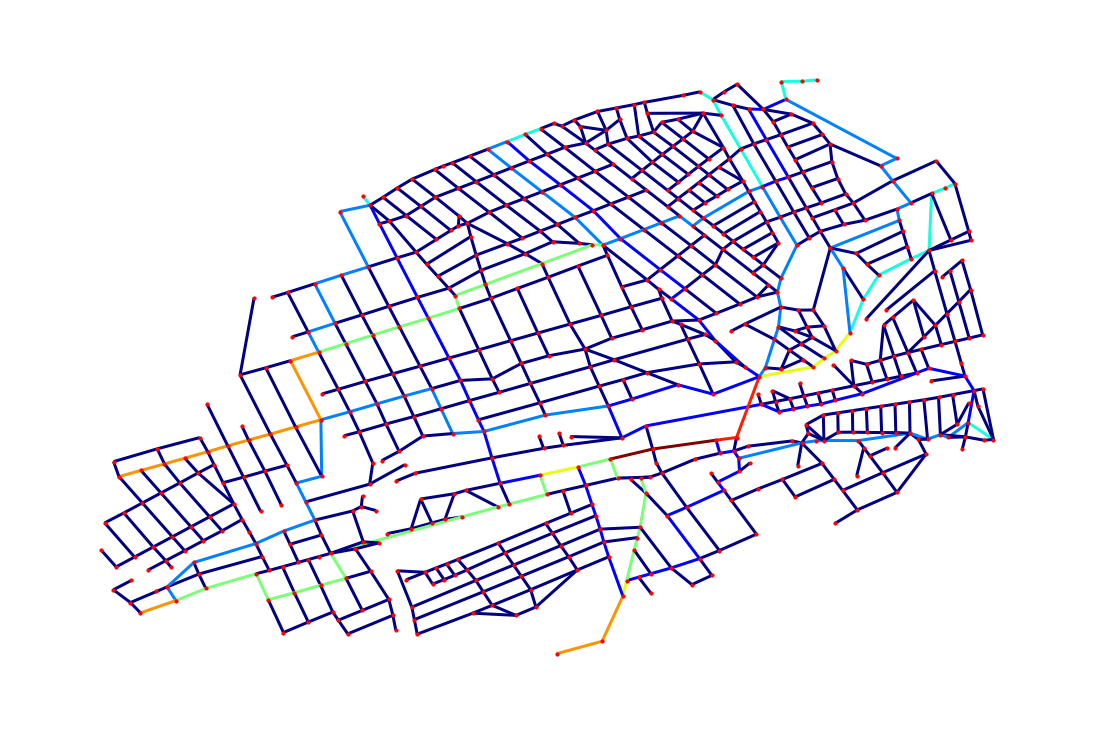

In [10]:
# the nice plot
plt.figure(figsize=(15,10))
nx.draw(G,pos,node_size=10,with_labels=False,edge_color=cars,edge_cmap=plt.cm.jet,node_color='red',width=3)

In [9]:
g = ig.Graph.from_networkx(G)

print(g.vs.attributes())

['_nx_name', 'x', 'y', 'label']


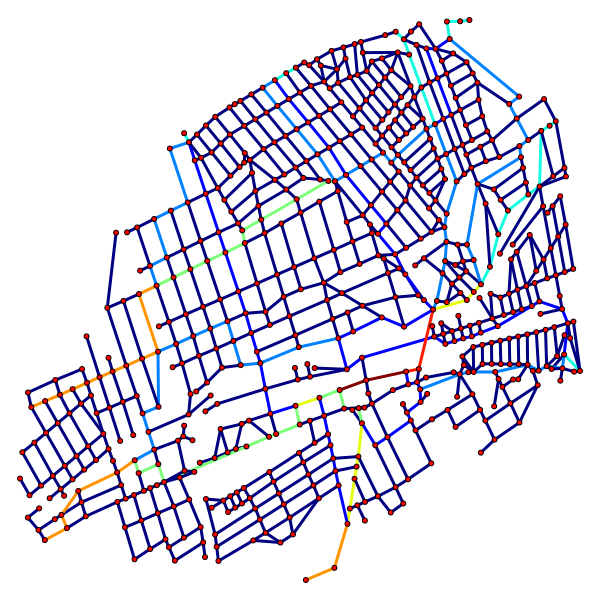

In [ ]:
name_to_index = {v["_nx_name"]: v.index for v in g.vs}
in_nodes = [name_to_index[n] for n in inout["in"]]
out_nodes = [name_to_index[n] for n in inout["out"]]
# Convert graph
g = ig.Graph.from_networkx(G)

# ----------------------------
# Create positions
# ----------------------------
pos = {}
posT = {}

for v in g.vs:
    lat = float(v["x"])
    lon = float(v["y"])

    pos[v.index] = (lat, -lon)
    posT[v.index] = (lon/180*np.pi, lat/180*np.pi)

layout = [pos[i] for i in range(g.vcount())]

ig.plot(
    g,
    layout=layout,
    vertex_size=5,
    vertex_color="red",
    vertex_label=None
)

# ----------------------------
# Edge attributes
# ----------------------------
g.es["length"] = [1] * g.ecount()
g.es["cars"] = [0] * g.ecount()

# ----------------------------
# Road arrays
# ----------------------------
roads0 = {}
roads1 = {}

for e in g.es:

    s = e.source
    t = e.target

    l = haversine_distances([posT[t]], [posT[s]])[0][0] * 6371000

    # safer id if none exists
    road_id = e["id"] if "id" in g.es.attributes() else e.index

    cells = int(l / 7)

    roads0[road_id] = np.zeros(cells, dtype=int)
    roads1[road_id] = np.zeros(cells, dtype=int)

    e["length"] = max(1, cells)

# ----------------------------
# Shortest paths
# ----------------------------
for i in in_nodes:
    for o in out_nodes:

        path = g.get_shortest_paths(i, to=o, output="vpath")[0]

        for u, v in zip(path[:-1], path[1:]):
            eid = g.get_eid(u, v)
            g.es[eid]["cars"] += 1

# ----------------------------
# Plot colored edges
# ----------------------------
cars = g.es["cars"]


cars = np.array(g.es["cars"])

norm = mcolors.Normalize(vmin=cars.min(), vmax=cars.max())
cmap = matplotlib.colormaps.get_cmap("jet")

edge_colors = [cmap(norm(v)) for v in cars]

ig.plot(
    g,
    layout=layout,
    vertex_size=5,
    vertex_color="red",
    vertex_label=None,
    edge_width=3,
    edge_color=edge_colors
)

# Traffic control optimization

## The task is to optimize the traffic control of central Érd in order to facilitate travel
`
The story is that there is an accident on the Highway M7 and all the traffic is going through Érd. Your task is to keep Érd livable but also allow the traffic to go through.

1. You are given a graph road network of central Érd, where the roundabouts were removed. You are supposed to read the erd.gexf file. The data contains the id of the junctions, their GPS coordinates (parameters x and y) and the connections among them  
2. There is a second file (inout.json) which contains the ids of the junctions where the through traffic enters and exits Érd  
3. Discretize the roads of Érd in the following way:  
   1. All roads  (segment between two junctions, please note that there are dead ends) are considered two-way single lane  
   2. All roads must be divided into *n≥*1 segments  
   3. `n=max(1,int(l/7))`
   4. The above code goes this far ---
4. Each segment can contain one single car and a car occupies always one single segment or a junction.  
5. Time is moving in timesteps  
6. Cars move on the road by the Nagel-Schreckenberg model with *v*max\=2. The model is defined as follows:  
   1. All cars have integer velocities $v_i=0,1,2$
   2. At each timestep we execute the following steps:  
   3. **Acceleration:** A car increases its velocity by 1 up to the maximum of  $v_\mathrm{max}=2$  
   4. **Breaking:** speed is reduced to the free distance ahead (car or junction) (if the free distance is larger do nothing, if there is another car just in front of this car then the velocity will be 0\)  
   5. **Randomization:** With probability *pr*\=0.1 each car which has a velocity larger than zero will  reduce its velocity by one  
   6. **Motion:** Cars move ahead $v_i$ number of segments  
7. Cars at the last segment of a road can go to the next intended road if that is available and the rules below allow it. There are no cars in the junction  
8. In the crossings there are traffic lights or nothing  
   1. If there are **no traffic lights** in the crossing, then the right-hand rule applies. If no car would move because e.g. all incoming roads are full, or the one with priority cannot go, then choose one who may move and move it.  
   2. If **there are traffic lights**, then one single incoming road gets green and cars may enter the crossing and leave it provided the road they are heading to has an empty space at the end. Only half of the roads may get green at any given moment.  
9. **Incoming cars:** There are 6 incoming junctions. They are always full. So if the car there managed to move it will be replaced by a new one. The incoming cars must reach an exit point. The road and exit it takes must be determined by your program. The number of cars exited the city is *E*  
10. **Local cars:** There are 500 local cars which make random walks on the streets. First run a simulation with only local cars and no traffic lights. Measure $v_0$ the average velocity of the local cars this will be your reference point.  
11. The simulation runs for 100 000 timesteps   
12. After timestep 50 000 record the velocity of the local cars and average it though the rest of the time. This average velocity will be denoted as $v_{av}$

## Task

Optimize the traffic by placing traffic lights and setting programs. The target to optimize:  
$$\frac{E(v_0-v_{av})^2}{v_0^2}$$




In [ ]:
import numpy as np
import random
from sklearn.metrics.pairwise import haversine_distances


class Car:
    def __init__(self, car_id, route):
        self.id = car_id
        self.route = route
        self.road_index = 0
        self.cell = 0
        self.v = 0


class RoadSegment:
    def __init__(self, edge_id, length):
        self.edge_id = edge_id
        self.length = length
        self.cells_fwd = [None] * length
        self.cells_bwd = [None] * length


class Junction:
    def __init__(self, node_id):
        self.node_id = node_id
        self.in_roads = []
        self.out_roads = []
        self.has_lights = False
        self.green_roads = set()


class TrafficNetwork:

    def __init__(self, g):
        self.graph = g
        self.roads = {}
        self.junctions = {}

        for v in g.vs:
            self.junctions[v.index] = Junction(v.index)

    def discretize(self, posT):

        for e in self.graph.es:

            s = e.source
            t = e.target

            l = haversine_distances(
                [posT[t]], [posT[s]]
            )[0][0] * 6371000

            n = max(1, int(l / 7))

            self.roads[e.index] = RoadSegment(e.index, n)

            self.junctions[s].out_roads.append(e.index)
            self.junctions[t].in_roads.append(e.index)

    def assign_traffic_lights(self, min_incoming=3, prob=0.5):

        for j in self.junctions.values():

            if len(j.in_roads) >= min_incoming and random.random() < prob:

                j.has_lights = True

                if j.in_roads:
                    j.green_roads = {j.in_roads[0]}


def compute_routes(g, in_nodes, out_nodes):

    routes = []

    for i in in_nodes:
        for o in out_nodes:

            path = g.get_shortest_paths(
                i,
                to=o,
                output="epath"
            )[0]

            if len(path) > 0:
                routes.append(path)

    return routes


def update_velocity(car, free_dist, vmax=2, pr=0.1):

    car.v = min(car.v + 1, vmax)
    car.v = min(car.v, free_dist)

    if car.v > 0 and np.random.rand() < pr:
        car.v -= 1


def right_hand_priority(cars):
    return sorted(cars, key=lambda c: c.route[c.road_index])


class TrafficSimulation:

    def __init__(self, network, routes):

        self.network = network
        self.routes = routes
        self.cars = []
        self.time = 0
        self.next_car_idx = 0

    def spawn_car(self, route):

        first_road = self.network.roads[route[0]]

        if first_road.cells_fwd[0] is not None:
            return

        car = Car(self.next_car_idx, route)
        self.next_car_idx += 1

        first_road.cells_fwd[0] = car.id
        car.cell = 0

        self.cars.append(car)

    def compute_free_distance(self, car, road):

        pos = car.cell
        dist = 0

        for i in range(pos + 1, road.length):

            if road.cells_fwd[i] is None:
                dist += 1
            else:
                break

        return dist

    def collect_waiting(self):

        waiting = {}

        for car in self.cars:

            road = self.network.roads[car.route[car.road_index]]

            if car.cell == road.length - 1:

                node = self.network.graph.es[road.edge_id].target
                waiting.setdefault(node, []).append(car)

        return waiting

    def resolve_junctions(self, waiting):

        for node, cars in waiting.items():

            junc = self.network.junctions[node]

            if junc.has_lights:

                cars = [
                    c for c in cars
                    if c.route[c.road_index] in junc.green_roads
                ]

            else:

                cars = right_hand_priority(cars)

            for car in list(cars):

                road = self.network.roads[car.route[car.road_index]]

                # leaving the network
                if car.road_index + 1 >= len(car.route):

                    road.cells_fwd[car.cell] = None
                    if car in self.cars:
                        self.cars.remove(car)
                    continue

                next_road_id = car.route[car.road_index + 1]
                next_road = self.network.roads[next_road_id]

                if next_road.cells_fwd[0] is None:

                    road.cells_fwd[car.cell] = None

                    car.road_index += 1
                    car.cell = 0

                    next_road.cells_fwd[0] = car.id

    def move_inside_road(self, car):

        road = self.network.roads[car.route[car.road_index]]

        new_pos = car.cell + car.v

        road.cells_fwd[car.cell] = None

        if new_pos < road.length:

            car.cell = new_pos

        else:

            car.cell = road.length - 1

        road.cells_fwd[car.cell] = car.id

    def update_lights(self):

        for j in self.network.junctions.values():

            if not j.has_lights:
                continue

            incoming = j.in_roads

            if len(incoming) == 0:
                continue

            half = max(1, len(incoming) // 2)

            start = self.time % len(incoming)

            j.green_roads = set(
                incoming[start:start + half]
            )

    def step(self):

        waiting = self.collect_waiting()

        for car in self.cars:

            road = self.network.roads[car.route[car.road_index]]

            if car.cell == road.length - 1:
                continue

            free = self.compute_free_distance(car, road)
            update_velocity(car, free)

        self.resolve_junctions(waiting)

        for car in list(self.cars):

            road = self.network.roads[car.route[car.road_index]]

            if car.cell == road.length - 1:
                continue

            self.move_inside_road(car)

        self.update_lights()

        self.time += 1

    def initialize_random_cars(self, n_cars):

        # map road -> routes containing that road
        road_to_routes = {}

        for r in self.routes:
            for i, road_id in enumerate(r):
                road_to_routes.setdefault(road_id, []).append((r, i))

        # collect all cells in the network
        all_cells = []

        for road_id, road in self.network.roads.items():
            for cell in range(road.length):
                all_cells.append((road_id, cell))

        if n_cars > len(all_cells):
            raise ValueError("More cars requested than total cells")

        chosen_cells = random.sample(all_cells, n_cars)

        for road_id, cell in chosen_cells:

            if road_id not in road_to_routes:
                continue

            route, idx = random.choice(road_to_routes[road_id])

            car = Car(self.next_car_idx, route)
            self.next_car_idx += 1

            car.road_index = idx
            car.cell = cell

            road = self.network.roads[road_id]
            road.cells_fwd[cell] = car.id

            self.cars.append(car)
            
def road_density(network):

    density = []

    for road in network.roads.values():

        occ = sum(c is not None for c in road.cells_fwd)

        density.append(occ / road.length)

    return density

In [127]:
import random
network = TrafficNetwork(g)
network.discretize(posT)
network.assign_traffic_lights()
routes = compute_routes(g, in_nodes, out_nodes)
sim = TrafficSimulation(network, routes)
sim.initialize_random_cars(500)

print(len(sim.cars))

for t in range(10000):

    if np.random.rand() < 0.7:
        sim.spawn_car(random.choice(routes))

    sim.step()

/tmp/ipykernel_10918/2396415580.py:278: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  dist = self.network.graph.shortest_paths(


In [128]:
def density_to_colors(network):

    densities = []

    for e in network.graph.es:
        road = network.roads[e.index]

        occ = sum(c is not None for c in road.cells_fwd)
        dens = occ / road.length
        densities.append(dens)

    densities = np.array(densities)

    vmax = max(densities.max(), 0.01)

    norm = mcolors.Normalize(vmin=0, vmax=vmax)
    cmap = matplotlib.colormaps.get_cmap("jet")

    colors = [cmap(norm(v)) for v in densities]

    return colors

def plot_network(g, network, layout):

    colors = density_to_colors(network)

    ig.plot(
        g,
        layout=layout,
        vertex_size=5,
        vertex_color="black",
        vertex_label=None,
        edge_width=3,
        edge_color=colors,
        target="traffic.png"
    )

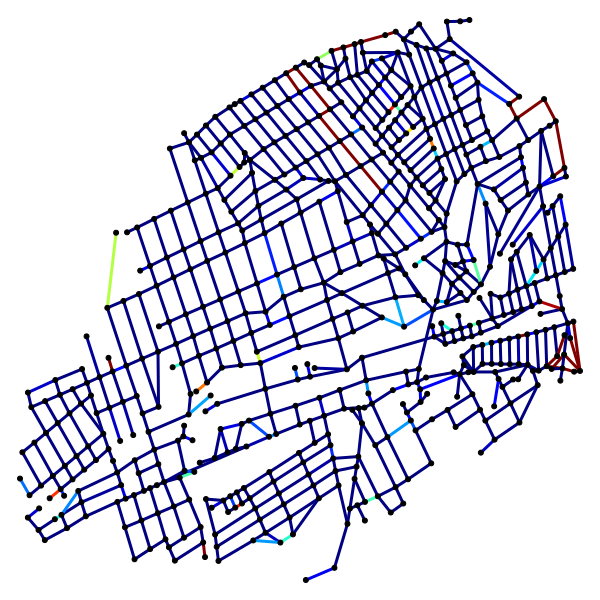

In [129]:
colors = density_to_colors(network)

ig.plot(
    g,
    layout=layout,
    vertex_size=5,
    vertex_color="black",
    vertex_label=None,
    edge_width=3,
    edge_color=colors,
    # target="traffic.png"
)

In [120]:
tot = 0
tot2 = 0
for road in network.roads:
    s = sum(c is not None for c in network.roads[road].cells_fwd)
    ss = len(network.roads[road].cells_fwd+network.roads[road].cells_bwd)
    # print(road, s)
    tot += s
    tot2 += ss
print(len(sim.cars), tot, tot2)

239 239 37372


In [122]:
valid_cells = 0

road_to_routes = {}

for r in sim.routes:
    road_to_routes.setdefault(r[0], []).append(r)
            
for road_id, road in network.roads.items():
    if road_id in road_to_routes:
        valid_cells += road.length

print(valid_cells)

68


In [ ]:
from __future__ import annotations

import random
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import igraph as ig
from sklearn.metrics.pairwise import haversine_distances


# ============================================================
# Data structures
# ============================================================


@dataclass
class Car:
    """Vehicle in the simulation."""
    id: int
    destination: int
    road_id: int
    cell: int
    velocity: int = 0
    prev_road: Optional[int] = None


class RoadSegment:
    """
    Discretized road edge.
    Each direction has its own cell array.
    """

    def __init__(self, edge_id: int, length: int) -> None:

        self.edge_id: int = edge_id
        self.length: int = length

        self.cells_fwd: List[Optional[int]] = [None] * length
        self.cells_bwd: List[Optional[int]] = [None] * length


class Junction:
    """Graph node representing an intersection."""

    def __init__(self, node_id: int) -> None:

        self.node_id: int = node_id
        self.in_roads: List[int] = []
        self.out_roads: List[int] = []

        self.has_lights: bool = False
        self.green_roads: set[int] = set()


# ============================================================
# Traffic network
# ============================================================


class TrafficNetwork:

    def __init__(self, g: ig.Graph):

        self.graph: ig.Graph = g
        self.roads: Dict[int, RoadSegment] = {}
        self.junctions: Dict[int, Junction] = {}

        for v in g.vs:
            self.junctions[v.index] = Junction(v.index)

    # --------------------------------------------------------

    def discretize(self, posT: Dict[int, Tuple[float, float]]) -> None:
        """
        Convert graph edges into Nagel–Schreckenberg cell arrays.
        """

        for e in self.graph.es:

            s = e.source
            t = e.target

            length_m = haversine_distances(
                [posT[t]],
                [posT[s]]
            )[0][0] * 6371000

            cells = max(1, int(length_m / 7))

            self.roads[e.index] = RoadSegment(e.index, cells)

            self.junctions[s].out_roads.append(e.index)
            self.junctions[t].in_roads.append(e.index)

    # --------------------------------------------------------

    def assign_traffic_lights(self,
                              min_incoming: int = 3,
                              prob: float = 0.5) -> None:

        for j in self.junctions.values():

            if len(j.in_roads) >= min_incoming and random.random() < prob:

                j.has_lights = True
                j.green_roads = {j.in_roads[0]}


# ============================================================
# Nagel-Schreckenberg rules
# ============================================================


def update_velocity(v: int,
                    free_dist: int,
                    vmax: int = 2,
                    pr: float = 0.1) -> int:
    """
    Classic NaSch update.
    """

    v = min(v + 1, vmax)
    v = min(v, free_dist)

    if v > 0 and random.random() < pr:
        v -= 1

    return v


# ============================================================
# Simulation
# ============================================================


class TrafficSimulation:

    def __init__(self,
                 network: TrafficNetwork,
                 exit_nodes: List[int],
                 entry_nodes: List[int]):

        self.network = network

        self.exit_nodes = exit_nodes
        self.entry_nodes = entry_nodes

        self.cars: Dict[int, Car] = {}

        self.time: int = 0
        self.next_car_id: int = 0

    # --------------------------------------------------------

    def create_car(self,
                   road_id: int,
                   cell: int,
                   destination: int) -> Optional[Car]:

        road = self.network.roads[road_id]

        if road.cells_fwd[cell] is not None:
            return None

        car = Car(
            id=self.next_car_id,
            destination=destination,
            road_id=road_id,
            cell=cell
        )

        self.next_car_id += 1

        road.cells_fwd[cell] = car.id
        self.cars[car.id] = car

        return car

    # --------------------------------------------------------

    def initialize_random_cars(self, n: int) -> None:
        """
        Snapshot initialization.
        Cars placed randomly anywhere in network.
        """

        all_cells: List[Tuple[int, int]] = []

        for road_id, road in self.network.roads.items():
            for c in range(road.length):
                all_cells.append((road_id, c))

        chosen = random.sample(all_cells, n)

        for road_id, cell in chosen:

            destination = random.choice(self.exit_nodes)

            self.create_car(road_id, cell, destination)

    # --------------------------------------------------------

    def spawn_at_entries(self, rate: float = 0.3) -> None:
        """
        Spawn cars at entry nodes.
        """

        if random.random() > rate:
            return

        node = random.choice(self.entry_nodes)

        j = self.network.junctions[node]

        if not j.out_roads:
            return

        road_id = random.choice(j.out_roads)
        road = self.network.roads[road_id]

        if road.cells_fwd[0] is not None:
            return

        dest = random.choice(self.exit_nodes)

        self.create_car(road_id, 0, dest)

    # --------------------------------------------------------

    def compute_free_distance(self,
                              road: RoadSegment,
                              pos: int) -> int:

        dist = 0

        for i in range(pos + 1, road.length):

            if road.cells_fwd[i] is None:
                dist += 1
            else:
                break

        return dist

    # --------------------------------------------------------

    def choose_next_road(self,
                         car: Car,
                         node: int) -> Optional[int]:
        """
        Choose outgoing road moving toward destination.
        """

        j = self.network.junctions[node]

        candidates = []

        for r in j.out_roads:

            if r == car.prev_road:
                continue

            target = self.network.graph.es[r].target

            candidates.append((r, target))

        if not candidates:
            return None

        dest = car.destination

        best = None
        best_dist = float("inf")

        for r, target in candidates:

            dist = self.network.graph.shortest_paths(
                source=target,
                target=dest
            )[0][0]

            if dist < best_dist:
                best = r
                best_dist = dist

        return best

    # --------------------------------------------------------

    def move_inside_roads(self) -> None:

        for car in list(self.cars.values()):

            road = self.network.roads[car.road_id]

            if car.cell == road.length - 1:
                continue

            free = self.compute_free_distance(road, car.cell)

            car.velocity = update_velocity(car.velocity, free)

            new_pos = car.cell + car.velocity

            road.cells_fwd[car.cell] = None

            car.cell = min(new_pos, road.length - 1)

            road.cells_fwd[car.cell] = car.id

    # --------------------------------------------------------

    def resolve_junctions(self) -> None:

        for car in list(self.cars.values()):

            road = self.network.roads[car.road_id]

            if car.cell != road.length - 1:
                continue

            node = self.network.graph.es[road.edge_id].target

            if node == car.destination:

                road.cells_fwd[car.cell] = None
                del self.cars[car.id]
                continue

            next_road = self.choose_next_road(car, node)

            if next_road is None:
                continue

            next_r = self.network.roads[next_road]

            if next_r.cells_fwd[0] is not None:
                continue

            road.cells_fwd[car.cell] = None

            car.prev_road = car.road_id
            car.road_id = next_road
            car.cell = 0

            next_r.cells_fwd[0] = car.id

    # --------------------------------------------------------

    def update_lights(self) -> None:

        for j in self.network.junctions.values():

            if not j.has_lights:
                continue

            incoming = j.in_roads

            if not incoming:
                continue

            idx = self.time % len(incoming)

            j.green_roads = {incoming[idx]}

    # --------------------------------------------------------

    def step(self) -> None:

        self.move_inside_roads()

        self.resolve_junctions()

        self.update_lights()

        self.spawn_at_entries()

        self.time += 1


# ============================================================
# Utility
# ============================================================


def road_density(network: TrafficNetwork) -> List[float]:

    density = []

    for road in network.roads.values():

        occ = sum(c is not None for c in road.cells_fwd)

        density.append(occ / road.length)

    return density

In [ ]:
network = TrafficNetwork(g)
network.discretize(posT)
network.assign_traffic_lights()

sim = TrafficSimulation(network, out_nodes, in_nodes)

sim.initialize_random_cars(500)

for t in range(10000):
    sim.step()

In [ ]:
colors = density_to_colors(network)

ig.plot(
    g,
    layout=layout,
    vertex_size=5,
    vertex_color="black",
    vertex_label=None,
    edge_width=3,
    edge_color=colors,
    # target="traffic.png"
)

In [130]:
from __future__ import annotations

import random
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import igraph as ig
from sklearn.metrics.pairwise import haversine_distances


# ============================================================
# Data structures
# ============================================================


@dataclass
class Car:
    """
    Represents a vehicle in the simulation.
    """
    id: int

    road_id: int
    cell: int

    destination_road: int
    destination_cell: int

    velocity: int = 0
    prev_road: Optional[int] = None


class RoadSegment:
    """
    Discretized road edge for NaSch model.
    """

    def __init__(self, edge_id: int, length: int):

        self.edge_id: int = edge_id
        self.length: int = length

        # one lane per direction
        self.cells_fwd: List[Optional[int]] = [None] * length
        self.cells_bwd: List[Optional[int]] = [None] * length


class Junction:
    """
    Graph node representing an intersection.
    """

    def __init__(self, node_id: int):

        self.node_id = node_id

        self.in_roads: List[int] = []
        self.out_roads: List[int] = []

        self.has_lights: bool = False
        self.green_roads: set[int] = set()


# ============================================================
# Network
# ============================================================


class TrafficNetwork:

    def __init__(self, g: ig.Graph):

        self.graph = g

        self.roads: Dict[int, RoadSegment] = {}
        self.junctions: Dict[int, Junction] = {}

        for v in g.vs:
            self.junctions[v.index] = Junction(v.index)

    # --------------------------------------------------------

    def discretize(self, posT: Dict[int, Tuple[float, float]]) -> None:
        """
        Convert graph edges into cell arrays.
        """

        for e in self.graph.es:

            s = e.source
            t = e.target

            length_m = haversine_distances(
                [posT[t]],
                [posT[s]]
            )[0][0] * 6371000

            cells = max(1, int(length_m / 7))

            self.roads[e.index] = RoadSegment(e.index, cells)

            self.junctions[s].out_roads.append(e.index)
            self.junctions[t].in_roads.append(e.index)

    # --------------------------------------------------------

    def assign_traffic_lights(
        self,
        min_incoming: int = 3,
        prob: float = 0.5
    ) -> None:

        for j in self.junctions.values():

            if len(j.in_roads) >= min_incoming and random.random() < prob:

                j.has_lights = True
                j.green_roads = {j.in_roads[0]}


# ============================================================
# Nagel-Schreckenberg rules
# ============================================================


def update_velocity(
    velocity: int,
    free_distance: int,
    vmax: int = 2,
    pr: float = 0.1
) -> int:
    """
    Classic NaSch velocity update.
    """

    velocity = min(velocity + 1, vmax)
    velocity = min(velocity, free_distance)

    if velocity > 0 and random.random() < pr:
        velocity -= 1

    return velocity


# ============================================================
# Simulation
# ============================================================


class TrafficSimulation:

    def __init__(
        self,
        network: TrafficNetwork,
        entry_nodes: List[int]
    ):

        self.network = network
        self.entry_nodes = entry_nodes

        self.cars: Dict[int, Car] = {}

        self.time = 0
        self.next_car_id = 0

    # --------------------------------------------------------

    def random_destination(self) -> Tuple[int, int]:
        """
        Select a random destination cell anywhere in network.
        """

        road_id = random.choice(list(self.network.roads.keys()))
        road = self.network.roads[road_id]

        cell = random.randrange(road.length)

        return road_id, cell

    # --------------------------------------------------------

    def create_car(
        self,
        road_id: int,
        cell: int
    ) -> Optional[Car]:

        road = self.network.roads[road_id]

        if road.cells_fwd[cell] is not None:
            return None

        dest_road, dest_cell = self.random_destination()

        car = Car(
            id=self.next_car_id,
            road_id=road_id,
            cell=cell,
            destination_road=dest_road,
            destination_cell=dest_cell
        )

        self.next_car_id += 1

        road.cells_fwd[cell] = car.id
        self.cars[car.id] = car

        return car

    # --------------------------------------------------------

    def initialize_random_cars(self, n: int) -> None:
        """
        Snapshot initialization.
        """

        all_cells = []

        for road_id, road in self.network.roads.items():
            for c in range(road.length):
                all_cells.append((road_id, c))

        chosen = random.sample(all_cells, n)

        for road_id, cell in chosen:
            self.create_car(road_id, cell)

    # --------------------------------------------------------

    def spawn_random(self, rate: float = 0.2) -> None:
        """
        Random spawn anywhere in network.
        """

        if random.random() > rate:
            return

        road_id = random.choice(list(self.network.roads.keys()))
        road = self.network.roads[road_id]

        cell = random.randrange(road.length)

        self.create_car(road_id, cell)

    # --------------------------------------------------------

    def spawn_at_entries(self, rate: float = 0.3) -> None:
        """
        Spawn vehicles at entry nodes.
        """

        if random.random() > rate:
            return

        node = random.choice(self.entry_nodes)

        j = self.network.junctions[node]

        if not j.out_roads:
            return

        road_id = random.choice(j.out_roads)
        road = self.network.roads[road_id]

        if road.cells_fwd[0] is not None:
            return

        self.create_car(road_id, 0)

    # --------------------------------------------------------

    def compute_free_distance(
        self,
        road: RoadSegment,
        pos: int
    ) -> int:

        dist = 0

        for i in range(pos + 1, road.length):

            if road.cells_fwd[i] is None:
                dist += 1
            else:
                break

        return dist

    # --------------------------------------------------------

    def reached_destination(self, car: Car) -> bool:

        return (
            car.road_id == car.destination_road
            and car.cell >= car.destination_cell
        )

    # --------------------------------------------------------

    def choose_next_road(
        self,
        car: Car,
        node: int
    ) -> Optional[int]:
        """
        Choose outgoing road steering toward destination.
        """

        j = self.network.junctions[node]

        candidates = []

        for r in j.out_roads:

            if r == car.prev_road:
                continue

            target = self.network.graph.es[r].target

            candidates.append((r, target))

        if not candidates:
            return None

        dest_node = self.network.graph.es[car.destination_road].target

        best = None
        best_dist = float("inf")

        for r, target in candidates:

            dist = self.network.graph.shortest_paths(
                source=target,
                target=dest_node
            )[0][0]

            if dist < best_dist:
                best = r
                best_dist = dist

        return best

    # --------------------------------------------------------

    def move_inside_roads(self) -> None:

        for car in list(self.cars.values()):

            road = self.network.roads[car.road_id]

            if car.cell == road.length - 1:
                continue

            free = self.compute_free_distance(road, car.cell)

            car.velocity = update_velocity(car.velocity, free)

            new_pos = car.cell + car.velocity

            road.cells_fwd[car.cell] = None

            car.cell = min(new_pos, road.length - 1)

            road.cells_fwd[car.cell] = car.id

    # --------------------------------------------------------

    def resolve_junctions(self) -> None:

        for car in list(self.cars.values()):

            road = self.network.roads[car.road_id]

            if car.cell != road.length - 1:
                continue

            node = self.network.graph.es[road.edge_id].target

            next_road = self.choose_next_road(car, node)

            if next_road is None:
                continue

            next_r = self.network.roads[next_road]

            if next_r.cells_fwd[0] is not None:
                continue

            road.cells_fwd[car.cell] = None

            car.prev_road = car.road_id
            car.road_id = next_road
            car.cell = 0

            next_r.cells_fwd[0] = car.id

    # --------------------------------------------------------

    def remove_arrived(self) -> None:

        for car in list(self.cars.values()):

            if self.reached_destination(car):

                road = self.network.roads[car.road_id]
                road.cells_fwd[car.cell] = None

                del self.cars[car.id]

    # --------------------------------------------------------

    def update_lights(self) -> None:

        for j in self.network.junctions.values():

            if not j.has_lights:
                continue

            incoming = j.in_roads

            if not incoming:
                continue

            idx = self.time % len(incoming)

            j.green_roads = {incoming[idx]}

    # --------------------------------------------------------

    def step(self) -> None:

        self.move_inside_roads()

        self.resolve_junctions()

        self.remove_arrived()

        self.spawn_random()

        self.spawn_at_entries()

        self.update_lights()

        self.time += 1


# ============================================================
# Diagnostics
# ============================================================


def road_density(network: TrafficNetwork) -> List[float]:

    density = []

    for road in network.roads.values():

        occ = sum(c is not None for c in road.cells_fwd)

        density.append(occ / road.length)

    return density

In [131]:
network = TrafficNetwork(g)

network.discretize(posT)
network.assign_traffic_lights()

sim = TrafficSimulation(network, entry_nodes=in_nodes)

sim.initialize_random_cars(500)

for t in range(10000):
    sim.step()

print("cars:", len(sim.cars))

/tmp/ipykernel_10918/2691505769.py:333: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  dist = self.network.graph.shortest_paths(


cars: 2879


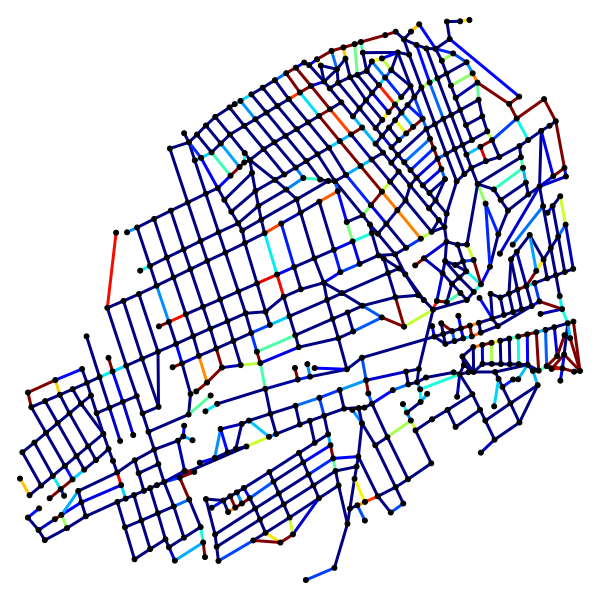

In [132]:
colors = density_to_colors(network)

ig.plot(
    g,
    layout=layout,
    vertex_size=5,
    vertex_color="black",
    vertex_label=None,
    edge_width=3,
    edge_color=colors,
    # target="traffic.png"
)

In [133]:
from __future__ import annotations

import random
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import igraph as ig
from sklearn.metrics.pairwise import haversine_distances


# ============================================================
# Vehicle
# ============================================================

@dataclass
class Car:
    id: int

    road_id: int
    cell: int

    destination_road: int
    destination_cell: int

    velocity: int = 0
    prev_road: Optional[int] = None


# ============================================================
# Road
# ============================================================

class RoadSegment:

    def __init__(self, edge_id: int, length: int):

        self.edge_id = edge_id
        self.length = length

        self.cells_fwd: List[Optional[int]] = [None] * length
        self.cells_bwd: List[Optional[int]] = [None] * length


# ============================================================
# Junction
# ============================================================

class Junction:

    def __init__(self, node_id: int):

        self.node_id = node_id

        self.in_roads: List[int] = []
        self.out_roads: List[int] = []

        self.has_lights = False
        self.green_roads: set[int] = set()


# ============================================================
# Network
# ============================================================

class TrafficNetwork:

    def __init__(self, g: ig.Graph):

        self.graph = g

        self.roads: Dict[int, RoadSegment] = {}
        self.junctions: Dict[int, Junction] = {}

        for v in g.vs:
            self.junctions[v.index] = Junction(v.index)

    def discretize(self, posT):

        for e in self.graph.es:

            s = e.source
            t = e.target

            l = haversine_distances([posT[t]], [posT[s]])[0][0] * 6371000

            cells = max(1, int(l / 7))

            self.roads[e.index] = RoadSegment(e.index, cells)

            self.junctions[s].out_roads.append(e.index)
            self.junctions[t].in_roads.append(e.index)

    def assign_traffic_lights(self, min_incoming=3, prob=0.5):

        for j in self.junctions.values():

            if len(j.in_roads) >= min_incoming and random.random() < prob:

                j.has_lights = True
                j.green_roads = {j.in_roads[0]}


# ============================================================
# Nagel-Schreckenberg rule
# ============================================================

def update_velocity(v, free_dist, vmax=2, pr=0.1):

    v = min(v + 1, vmax)
    v = min(v, free_dist)

    if v > 0 and random.random() < pr:
        v -= 1

    return v


# ============================================================
# Simulation
# ============================================================

class TrafficSimulation:

    def __init__(
        self,
        network: TrafficNetwork,
        entry_nodes: List[int],
        through_prob: float = 0.7
    ):

        self.network = network
        self.entry_nodes = entry_nodes
        self.through_prob = through_prob

        self.cars: Dict[int, Car] = {}

        self.time = 0
        self.next_car_id = 0

    # --------------------------------------------------------
    # DESTINATION SELECTION
    # --------------------------------------------------------

    def random_destination_cell(self):

        road_id = random.choice(list(self.network.roads.keys()))
        road = self.network.roads[road_id]

        cell = random.randrange(road.length)

        return road_id, cell

    def destination_entry_node(self, origin_node):

        candidates = [n for n in self.entry_nodes if n != origin_node]

        if not candidates:
            return self.random_destination_cell()

        node = random.choice(candidates)

        j = self.network.junctions[node]

        if not j.in_roads:
            return self.random_destination_cell()

        road_id = random.choice(j.in_roads)
        road = self.network.roads[road_id]

        return road_id, road.length - 1

    # --------------------------------------------------------
    # CAR CREATION
    # --------------------------------------------------------

    def create_car(self, road_id, cell, dest):

        road = self.network.roads[road_id]

        if road.cells_fwd[cell] is not None:
            return None

        dest_road, dest_cell = dest

        car = Car(
            id=self.next_car_id,
            road_id=road_id,
            cell=cell,
            destination_road=dest_road,
            destination_cell=dest_cell
        )

        self.next_car_id += 1

        road.cells_fwd[cell] = car.id
        self.cars[car.id] = car

        return car

    # --------------------------------------------------------
    # RANDOM INITIALIZATION
    # --------------------------------------------------------

    def initialize_random_cars(self, n):

        cells = []

        for r, road in self.network.roads.items():
            for c in range(road.length):
                cells.append((r, c))

        chosen = random.sample(cells, n)

        for r, c in chosen:

            dest = self.random_destination_cell()

            self.create_car(r, c, dest)

    # --------------------------------------------------------
    # ENTRY SPAWN
    # --------------------------------------------------------

    def spawn_at_entries(self, rate=0.3):

        if random.random() > rate:
            return

        node = random.choice(self.entry_nodes)

        j = self.network.junctions[node]

        if not j.out_roads:
            return

        road_id = random.choice(j.out_roads)
        road = self.network.roads[road_id]

        if road.cells_fwd[0] is not None:
            return

        if random.random() < self.through_prob:
            dest = self.destination_entry_node(node)
        else:
            dest = self.random_destination_cell()

        self.create_car(road_id, 0, dest)

    # --------------------------------------------------------
    # ROAD MOVEMENT
    # --------------------------------------------------------

    def compute_free_distance(self, road, pos):

        dist = 0

        for i in range(pos + 1, road.length):

            if road.cells_fwd[i] is None:
                dist += 1
            else:
                break

        return dist

    def move_inside_roads(self):

        for car in list(self.cars.values()):

            road = self.network.roads[car.road_id]

            if car.cell == road.length - 1:
                continue

            free = self.compute_free_distance(road, car.cell)

            car.velocity = update_velocity(car.velocity, free)

            new_pos = car.cell + car.velocity

            road.cells_fwd[car.cell] = None

            car.cell = min(new_pos, road.length - 1)

            road.cells_fwd[car.cell] = car.id

    # --------------------------------------------------------
    # JUNCTION ROUTING
    # --------------------------------------------------------

    def choose_next_road(self, car, node):

        j = self.network.junctions[node]

        candidates = []

        for r in j.out_roads:

            if r == car.prev_road:
                continue

            target = self.network.graph.es[r].target

            candidates.append((r, target))

        if not candidates:
            return None

        dest_node = self.network.graph.es[car.destination_road].target

        best = None
        best_dist = float("inf")

        for r, target in candidates:

            d = self.network.graph.shortest_paths(
                source=target,
                target=dest_node
            )[0][0]

            if d < best_dist:
                best = r
                best_dist = d

        return best

    def resolve_junctions(self):

        for car in list(self.cars.values()):

            road = self.network.roads[car.road_id]

            if car.cell != road.length - 1:
                continue

            node = self.network.graph.es[road.edge_id].target

            next_road = self.choose_next_road(car, node)

            if next_road is None:
                continue

            next_r = self.network.roads[next_road]

            if next_r.cells_fwd[0] is not None:
                continue

            road.cells_fwd[car.cell] = None

            car.prev_road = car.road_id
            car.road_id = next_road
            car.cell = 0

            next_r.cells_fwd[0] = car.id

    # --------------------------------------------------------
    # DESTINATION REMOVAL
    # --------------------------------------------------------

    def remove_arrived(self):

        for car in list(self.cars.values()):

            if (
                car.road_id == car.destination_road
                and car.cell >= car.destination_cell
            ):

                road = self.network.roads[car.road_id]
                road.cells_fwd[car.cell] = None

                del self.cars[car.id]

    # --------------------------------------------------------

    def step(self):

        self.move_inside_roads()

        self.resolve_junctions()

        self.remove_arrived()

        self.spawn_at_entries()

        self.time += 1

In [134]:
network = TrafficNetwork(g)

network.discretize(posT)
network.assign_traffic_lights()

sim = TrafficSimulation(network, entry_nodes=in_nodes)

sim.initialize_random_cars(500)

for t in range(10000):
    sim.step()

print("cars:", len(sim.cars))

/tmp/ipykernel_10918/3421052089.py:317: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  d = self.network.graph.shortest_paths(


cars: 1093


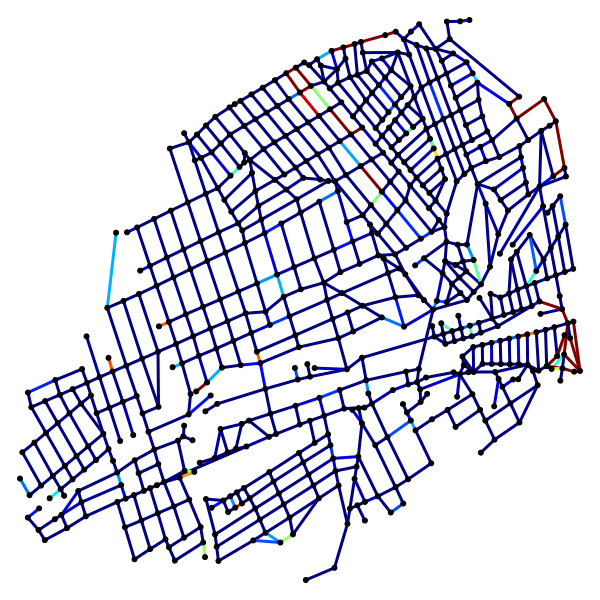

In [135]:
colors = density_to_colors(network)

ig.plot(
    g,
    layout=layout,
    vertex_size=5,
    vertex_color="black",
    vertex_label=None,
    edge_width=3,
    edge_color=colors,
    # target="traffic.png"
)